In [ ]:
#___________________________
# importing libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.express as px
import pyarrow.parquet as pq
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 9
matplotlib.rcParams['figure.figsize'] = (10, 6)

# -------------------------------------------
# | import file                              |
# --------------------------------------------
try:
  table=pq.read_table("/content/clean1.parquet")
  df=table.to_pandas()
except Exception as e:
   print(f"still error occured {e}")





In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65000 entries, 0 to 64999
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   rating                  65000 non-null  float64       
 1   title                   65000 non-null  object        
 2   review                  65000 non-null  object        
 3   asin                    65000 non-null  object        
 4   parent_asin             65000 non-null  object        
 5   timestamp               65000 non-null  int64         
 6   helpful_vote            65000 non-null  int64         
 7   verified_purchase       65000 non-null  bool          
 8   main_category           65000 non-null  object        
 9   average_rating          65000 non-null  float64       
 10  rating_number           65000 non-null  int64         
 11  price                   65000 non-null  float64       
 12  store                   65000 non-null  object

In [ ]:
fig=px.histogram(data_frame=df,x="review_year")
fig.show()

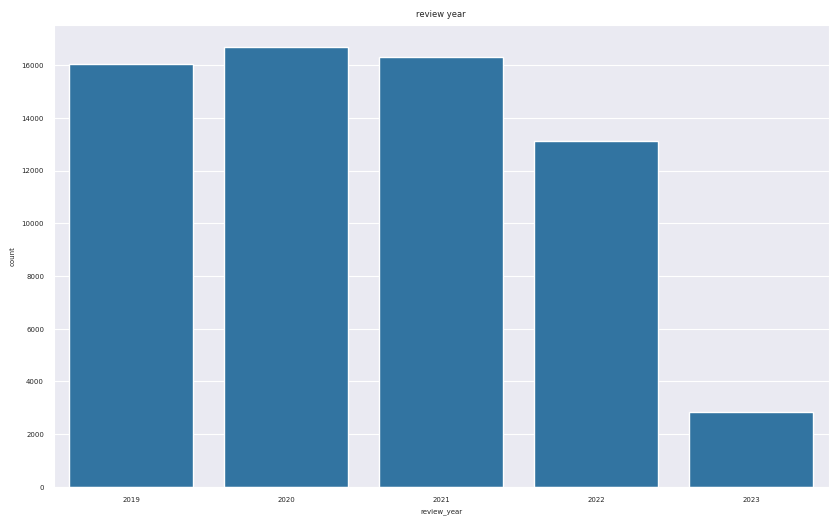

In [ ]:
sns.countplot(data=df,x="review_year")
plt.title("review year")
plt.show()

<Axes: xlabel='launch_year_alone', ylabel='count'>

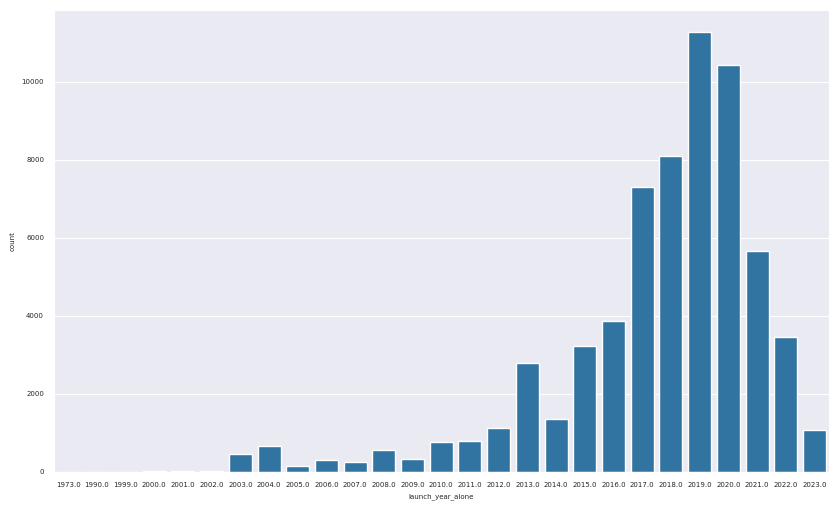

In [ ]:
df['launch_year_alone'] = pd.to_datetime(df['launch_year'], errors='coerce').dt.year
matplotlib.rcParams['font.size'] = 5
sns.countplot(data=df,x="launch_year_alone")

In [ ]:
df['launch_year_alone'].min()

1973.0

In [ ]:
df['launch_year_alone'].isnull().sum()

np.int64(910)

In [ ]:
df['launch_year_alone'] = pd.to_datetime(df['launch_year'], errors='coerce').dt.year
matplotlib.rcParams['font.size'] = 5

fig=px.histogram(data_frame=df,x="launch_year_alone",title="lauch year")
fig.show()

finding:
1.it seems that launch date has around noraml distribution ,and come from 2k peak at 2019

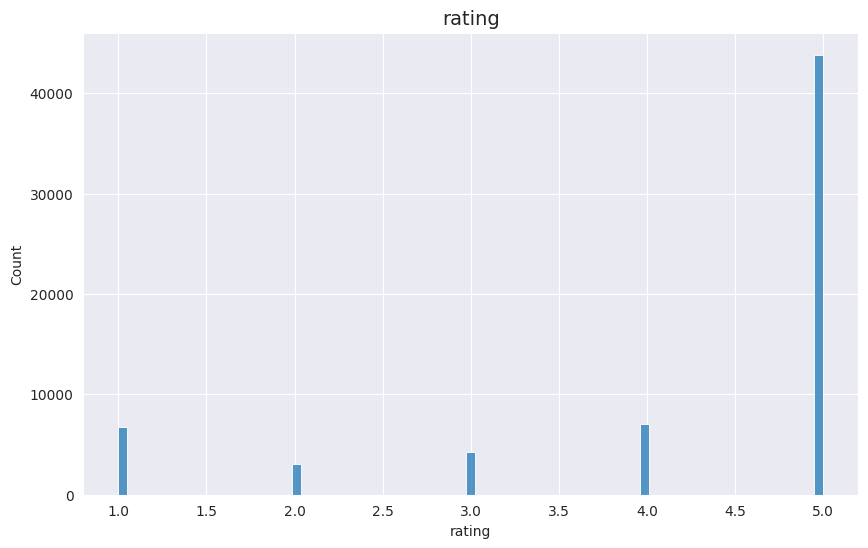

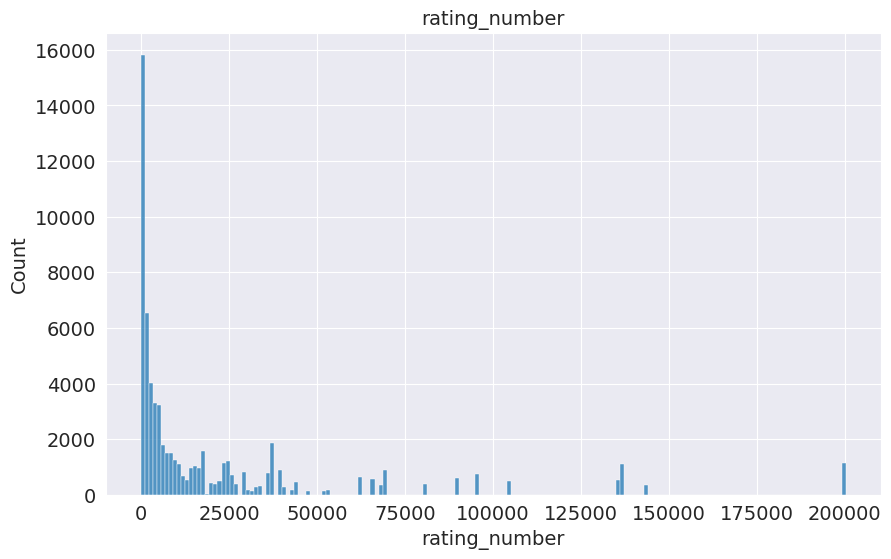

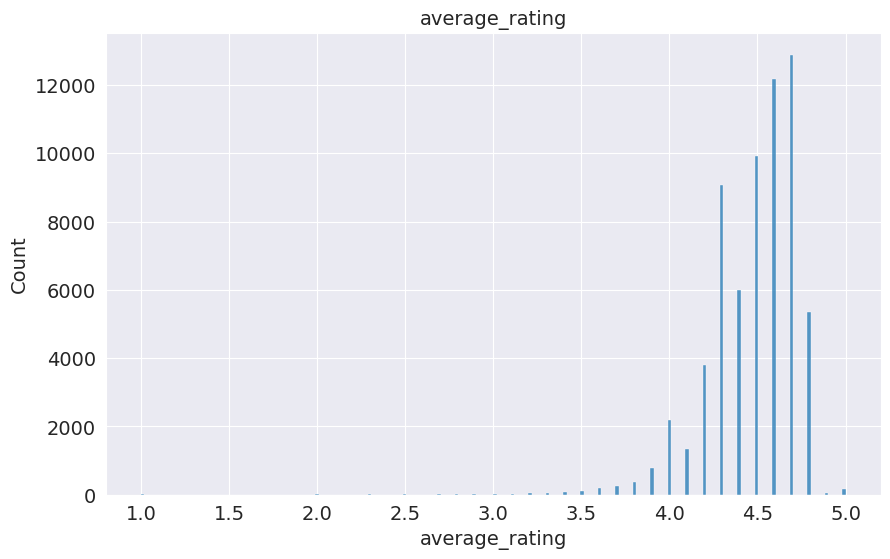

In [ ]:
columns=['rating','rating_number','average_rating']
for i in  columns:
  sns.histplot(data=df,x=i)
  matplotlib.rcParams['font.size'] = 14
  plt.title(f"{i}",fontsize=14)
  plt.show()

In [ ]:
columns=['rating','rating_number','average_rating','helpful_vote','features_length',
       'feature_word_count', 'features_bullet_count', 'has_warranty',
       'has_numbers', 'has_compatability', 'would_buy_again',
       'mentions_defect', 'review_word_count', 'sentiment_polarity','weight_gram',
       'dimension_d', 'description_length',
       'description_word_count','price']
for i in columns:
  fig=px.histogram(data_frame=df,x=i, title=f"{i}")
  fig.show()

In [ ]:
store_df=df['store'].unique()
len(store_df)

2669

rotation is used to rotate xticks 90 degree ha for align whichpart of label to number,tight layout for adjusting plot

/tmp/ipykernel_1094/1237473044.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=store_df.index, x=store_df.values, palette="viridis")


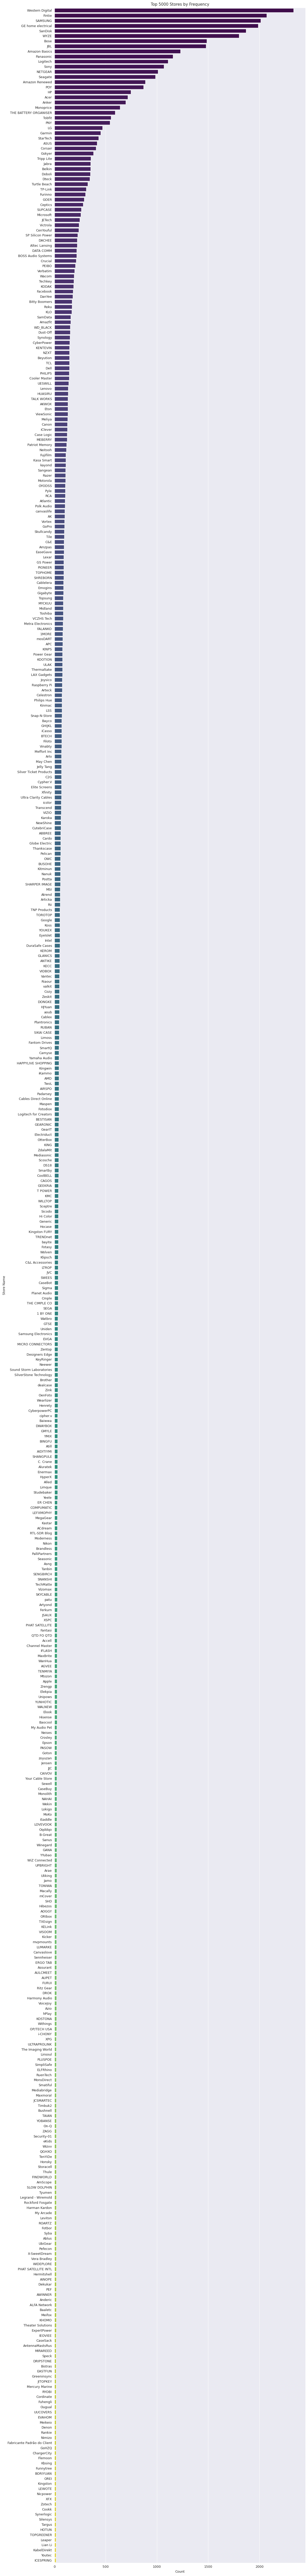

In [ ]:
store_df=df['store'].value_counts().head(500)

plt.figure(figsize=(12, 100)) # Increased height for 500 bars
sns.barplot(y=store_df.index, x=store_df.values, palette="viridis")
plt.title('Top 5000 Stores by Frequency')
plt.xlabel('Count')
plt.ylabel('Store Name')
# No need for x-tick rotation for horizontal plot, but will add tight layout
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()



In [ ]:
fig=px.histogram(data_frame=df,x='price', width=1500, height=900,title="price distribution")
matplotlib.rcParams['font.size'] = 18
fig.update_xaxes(range=[0, 1000])
fig.show()

creating heatmap

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65000 entries, 0 to 64999
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   rating                  65000 non-null  float64       
 1   title                   65000 non-null  object        
 2   review                  65000 non-null  object        
 3   asin                    65000 non-null  object        
 4   parent_asin             65000 non-null  object        
 5   timestamp               65000 non-null  int64         
 6   helpful_vote            65000 non-null  int64         
 7   verified_purchase       65000 non-null  bool          
 8   main_category           65000 non-null  object        
 9   average_rating          65000 non-null  float64       
 10  rating_number           65000 non-null  int64         
 11  price                   65000 non-null  float64       
 12  store                   65000 non-null  object

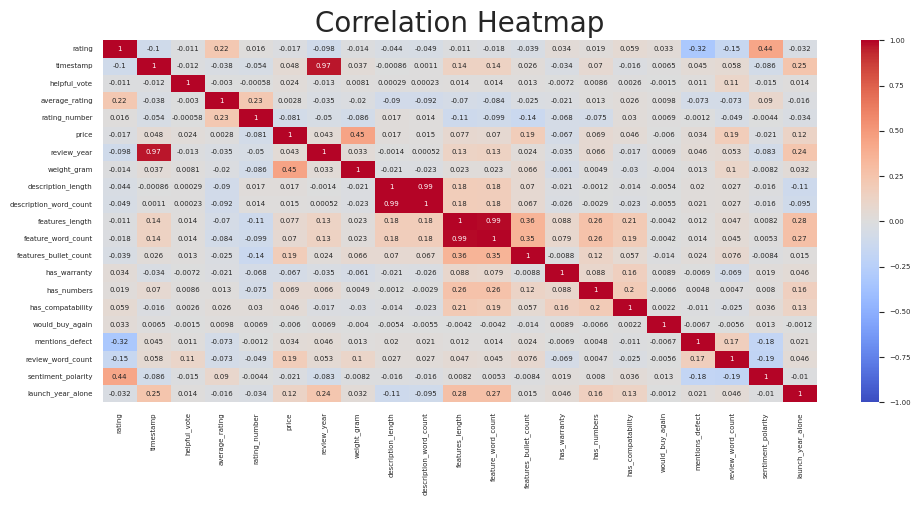

In [ ]:
number_df=df.select_dtypes(include=['float64','int64'])
corr_matrix=number_df.corr()
matplotlib.rcParams['font.size'] = 5
plt.figure(figsize=(10,5))
sns.heatmap(
    data=corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)
plt.title("Correlation Heatmap", fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
corr_matrix.to_csv("corr_matrix.csv")
files.download("corr_matrix.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

dropping columns

In [ ]:
df.drop(columns=['timestamp','helpful_vote','description_length','features_length','would_buy_again'],inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65000 entries, 0 to 64999
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   rating                  65000 non-null  float64       
 1   title                   65000 non-null  object        
 2   review                  65000 non-null  object        
 3   asin                    65000 non-null  object        
 4   parent_asin             65000 non-null  object        
 5   verified_purchase       65000 non-null  bool          
 6   main_category           65000 non-null  object        
 7   average_rating          65000 non-null  float64       
 8   rating_number           65000 non-null  int64         
 9   price                   65000 non-null  float64       
 10  store                   65000 non-null  object        
 11  categories              65000 non-null  object        
 12  review_datetime         65000 non-null  dateti

In [ ]:
df['verified_purchase'].value_counts()

,count
verified_purchase,
True,61549
False,3451


In [ ]:
df['asin'].value_counts()

,count
asin,
B08FFJWQY1,1016
B06W55K9N6,628
B08FFK9ZYR,517
B07RF1XD36,495
B0143RT8OY,403
...,...
B01EOYJIC8,1
B08R5BRXN3,1
B07FMP1Y16,1


creating product level dataset for more deeper understanding
create review year span ie,first review year-last review year

In [ ]:
df['launch_year']

,launch_year
0,2019-05-01
1,2021-01-19
2,2017-06-16
3,2021-01-19
4,2018-05-25
...,...
64995,2020-08-08
64996,2020-08-08
64997,2020-08-08
64998,2020-08-08


In [ ]:
at=product_df[['atomic_category','broad_category','product_name']]
from google.colab import files
at.to_csv("at.csv")
files.download("at.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pd.set_option('display.max_colwidth', None)
product_df[product_df['broad_category'] == 'Unnamed: 0'][['product_name','categories']]

,product_name,categories


In [ ]:
# from google.colab import files
# # Temporarily set display.max_rows to 100
# pd.set_option('display.max_rows', 100)

# # Display the first 100 rows of product_df


# # Reset display.max_rows to its default (usually 60) to avoid affecting other outputs
# pd.reset_option('display.max_rows')
# category2 = pd.DataFrame({
#     'subcatgory': product_df['subcatgory'],
#     'title': product_df['product_name'],
#     'categories': product_df['categories']
# })

# display(category2.head(100))
# # category2=category2.head(50)
# # category2.to_csv("subcatgory2.csv", index=False)
# # # files.download("subcatgory2.csv")
#  import pandas as pd
# category2=pd.read_csv("/content/subcatgory2 (1).csv")
# atomic_df=pd.read_csv("/content/final_categorized_data_v3.csv")
# specs_df=pd.read_csv("/content/spec_based_subcategories.csv")
# clean_df=pd.read_csv("/content/final_categorized_cleaned_v3.csv")
# category2['atomic_category']=atomic_df['Atomic_Category']
# category2['subcategory']=specs_df['Granular_Comparison_Subcategory']
# category2['final_subcatgory']=clean_df['final_category']
# category2['atomic_category'].value_counts()
# category2.drop(columns=['subcatgory','subcategory'],inplace=True)
# # category2.to_csv("catgory3.csv", index=False)
# # files.download("catgory3.csv")
# from google.colab import files
# # category2.to_csv("catgory2.csv", index=False)
# # files.download("catgory2.csv")
# # This line caused the error. If you want to count categories that appear exactly once:
# (category2['atomic_category'].value_counts() <= 10).sum()
# # If you want to filter the DataFrame to show only rows where the atomic_category appears once:
# # counts = category2['atomic_category'].value_counts()
# # single_occurrence_categories = counts[counts == 1].index
# # category2[category2['atomic_category'].isin(single_occurrence_categories)]
# # category2['subcategory'].value_counts()

asin is for different product same product from different categories get different asin

## Creating product_df and cleaning subcategories

In [ ]:
from matplotlib.cbook import print_cycles
import numpy as np
import pandas as pd
product_df= df.groupby('asin').agg(
    # product level metadata
    parent_asin  =('parent_asin','first'),
    main_category=('main_category','first'),
    store        =('store','first'),
    product_name =('title','first'),
    categories=('categories','first'),


    price              =('price','mean'),
    weight             =('weight_gram','mean'),
    dimension_d        =('dimension_d','first'),
    launch_year        =('launch_year','first'), # Changed from launch_date to launch_year based on product_df.info()


    # prelauch listing features
    feature_word_count =('feature_word_count','mean'),
    features_bullet_count=('features_bullet_count','mean'),
    description_word_count=('description_word_count','mean'),
    has_warranty       =('has_warranty','mean'),
    has_numbers        =('has_numbers','max'),
    has_compatability  =('has_compatability','mean'),
    # review signals
    mentions_defect    =('mentions_defect','mean'),
    review_word_count  =('review_word_count','mean'),
    first_review_date  =('review_datetime','min'),
    last_review_date   =('review_datetime','max'),
    # review_span        =first_review_year-last_review_year,

    average_rating     =('average_rating','mean'),
    rating_number      =('rating_number','max'),
    rating_mean             =('rating','mean'),

    review_count            =('review','count'),

    verified_purchase  =('verified_purchase','mean'),
    defect_mention_max= ('mentions_defect',       'max'),
    avg_sentiment      =('sentiment_polarity','mean')

).reset_index()


# to extract subcategorey
def extract_subcatgory(cat):
  if isinstance(cat,(list,np.ndarray)):
    return cat[-1] if len(cat)>0 else "unknown"
  if isinstance(cat,str):
    cleaned=cat.replace('[',"").replace(']',"").split(',')
    return cleaned[-1] if len(cleaned)>0 else "unknown"
  return "unknown"

product_df['subcategory']=product_df['categories'].apply(extract_subcatgory)
# filling lauch year column
mask = product_df['launch_year'] > product_df['first_review_date']

product_df.loc[mask, 'launch_year'] = product_df.loc[mask, 'first_review_date']
product_df['launch_year'] = product_df['launch_year'].fillna(product_df['first_review_date'])
# Convert 'launch_year' to datetime, coercing errors to NaT
product_df['launch_year'] = pd.to_datetime(product_df['launch_year'], errors='coerce')

product_df['launch_month']=product_df['launch_year'].dt.month # Corrected to use product_df['launch_year']

# Ensure product_age is at least 1 to avoid division by zero or negative values
product_df['product_age'] = np.maximum(1, (product_df['last_review_date'].dt.year - pd.to_datetime(product_df['launch_year']).dt.year) + 1)

product_df['ratings_per_year'] = (product_df['rating_number'] /product_df['product_age'])

product_df['reviews_per_year'] = ( product_df['review_count'] /product_df['product_age'])


# fill weight column

import pandas as pd
import numpy as np



# ── Step 1: Remove junk rows ──────────────────────────────────
JUNK = [
    'Bestselling Renewed Smartphones',
    'samsung_tradein',
    'New Arrivals - Electronics',
    'Electronics & Wireless Outlet',
    'V4 Customers Keep It - 50%',
    'LifeProof Brand Store',
    'Amazon Pro Portal',
    'SteelSeries',
    'Devices',
    'Accessories',
    'Accessories & Supplies',
    'Computers & Accessories',
    'Computer Accessories & Peripherals',
    'Camera & Photo',
    'Home Entertainment',
    'Portable Audio & Video',
    'Electronics',
    'Computers & Tablets',
]
product_df = product_df[~product_df['subcategory'].isin(JUNK)].copy()

# ── Step 2: Merge duplicates and fix names ────────────────────
MERGE_MAP = {
    # Cases
    'Cases':                    'Device Cases',
    'Hard Shell Cases':         'Device Cases',
    'Covers':                   'Device Cases',
    'Keyboard Cases':           'Device Cases',
    'iPhone Cases':             'Device Cases',

    # Sleeves
    'Sleeves':                  'Device Sleeves',
    'Cable Sleeves':            'Cable Management',
    'Cable Straps':             'Cable Management',
    'Cable Ties':               'Cable Management',
    'Cord Management':          'Cable Management',
    'Cable Raceways':           'Cable Management',
    'Floor Cord Covers':        'Cable Management',
    'Cable Organizer Bags & Cases': 'Cable Management',

    # Ethernet cables - merge all cat variants
    'Cat 5 Cables':             'Ethernet Cables',
    'Cat 5e Cables':            'Ethernet Cables',
    'Cat 6 Cables':             'Ethernet Cables',
    'Cat 7 Cables':             'Ethernet Cables',

    # Coaxial
    'Coaxial':                  'Coaxial Cables',


    # Optical
    'Optical':                  'Optical Cables',
    'Optical Drives':           'Optical Drives',

    # Video cables
    'DVI':                      'Video Cables',
    'VGA Cables':               'Video Cables',
    'Component Cables':         'Video Cables',
    'DVI-HDMI Adapters':        'Video Cables',
    'HDMI-to-VGA Adapters':     'Video Cables',

    # RCA
    'RCA':                      'RCA Cables',

    # Adapters - merge all
    'Adapters':                 'Adapters & Converters',
    'Computer Cable Adapters':  'Adapters & Converters',
    'USB-to-USB Adapters':      'Adapters & Converters',
    'USB-to-VGA Adapters':      'Adapters & Converters',
    'Gender Changers':          'Adapters & Converters',
    'Serial Adapters':          'Adapters & Converters',
    'Auxiliary Input Adapters': 'Adapters & Converters',
    'Cassette Player Adapters': 'Adapters & Converters',
    'DVI-HDMI Adapters':        'Adapters & Converters',
    'HDMI-to-VGA Adapters':     'Adapters & Converters',
    'Photo Adapters':           'Adapters & Converters',
    'Memory Card Adapters':     'Adapters & Converters',

    # Cables misc - merge vague ones
    'Cables':                   'Cables & Interconnects',
    'Cables & Cords':           'Cables & Interconnects',
    'Chargers & Cables':        'Cables & Interconnects',

    # Skins & Decals
    'Skins':                    'Skins & Decals',
    'Decals':                   'Skins & Decals',

    # Headphones - merge types
    'Earbud Headphones':        'Headphones',
    'Over-Ear Headphones':      'Headphones',
    'On-Ear Headphones':        'Headphones',
    'Headphones & Earbuds':     'Headphones',
    'Headphones, Earbuds & Accessories': 'Headphones',
    'Bluetooth Headsets':       'Headphones',
    'Computer Headsets':        'Headphones',
    'Headsets & Microphones':   'Headphones',

    # Speakers - merge types
    'Speaker':                  'Speakers',
    'Bookshelf Speakers':       'Speakers',
    'Outdoor Speakers':         'Speakers',
    'Computer Speakers':        'Speakers',
    'Ceiling & In-Wall Speakers': 'Speakers',
    'Center-Channel Speakers':  'Speakers',
    'Floorstanding Speakers':   'Speakers',
    'Marine Speakers':          'Speakers',
    'Component Subwoofers':     'Subwoofers',
    'Subwoofer Boxes & Enclosures': 'Subwoofers',
    'Enclosed Subwoofer Systems': 'Subwoofers',
    'Coaxial Speakers':         'Speakers',

    # Audio amplifiers
    'Amplifiers':               'Audio Amplifiers',
    'Multichannel Amplifiers':  'Audio Amplifiers',
    'Mono Amplifiers':          'Audio Amplifiers',
    'Audio Docks':              'Audio Amplifiers',
    'Preamplifiers':            'Audio Amplifiers',
    'Dual-Channel Amplifiers':  'Audio Amplifiers',
    'Receivers':                'Audio Amplifiers',

    # Storage - merge
    'Memory':                   'RAM',
    'Internal Hard Drives':     'Storage Drives',
    'Internal Solid State Drives': 'Storage Drives',
    'External Hard Drives':     'Storage Drives',
    'External Solid State Drives': 'Storage Drives',
    'USB Flash Drives':         'Storage Drives',
    'SD Cards':                 'Memory Cards',
    'Micro SD Cards':           'Memory Cards',
    'CompactFlash Cards':       'Memory Cards',
    'Memory Card Readers':      'Memory Cards',
    'Data Storage':             'Storage Drives',

    # Cameras - merge
    'Camera':                   'Digital Cameras',
    'Cameras':                  'Digital Cameras',
    'DSLR Cameras':             'Digital Cameras',
    'SLR Cameras':              'Digital Cameras',
    'SLR Camera Lenses':        'Camera Lenses',
    'Mirrorless Camera Lenses': 'Camera Lenses',
    'Point & Shoot Digital Cameras': 'Digital Cameras',
    'Instant Cameras':          'Digital Cameras',
    'Sports & Action Video Cameras': 'Action Cameras',
    'Camcorders':               'Action Cameras',
    'Camcorder':                'Action Cameras',
    'Single-Use Cameras':       'Digital Cameras',
    'Specialty Film Cameras':   'Film Cameras',
    'Simulated Cameras':        'Security Cameras',
    'Hidden Cameras':           'Security Cameras',
    'Bullet Cameras':           'Security Cameras',
    'Dome Cameras':             'Security Cameras',
    'Vehicle Backup Cameras':   'Security Cameras',

    # Camera accessories - merge
    'Camera Mounts & Clamps':   'Camera Mounts',
    'Camera Bags':              'Camera Bags & Cases',
    'Camera Cases':             'Camera Bags & Cases',
    'Hard Drive Bags & Cases':  'Camera Bags & Cases',
    'Bags, Cases & Sleeves':    'Camera Bags & Cases',

    # Filters - merge
    'Filter Sets':              'Camera Filters',
    'Polarizing Filters':       'Camera Filters',
    'Skylight & UV Filters':    'Camera Filters',
    'Neutral Density Filters':  'Camera Filters',
    'Screen Filters':           'Camera Filters',
    'Effects Filters':          'Camera Filters',
    'Infrared Filters':         'Camera Filters',
    'Anti-Glare & Privacy Filters': 'Camera Filters',
    'Filters':                  'Camera Filters',

    # Laptops
    'Traditional Laptops':      'Laptops',
    '2 in 1 Laptops':           'Laptops',
    'Minis':                    'Laptops',
    'All-in-Ones':              'Laptops',
    'Laptop Replacement Parts': 'Laptop Accessories',
    'Laptop Accessories':       'Laptop Accessories',

    # Power
    'Uninterruptible Power Supply (UPS)': 'UPS',
    'Line Conditioners':        'UPS',
    'Internal Power Supplies':  'Power Supplies',
    'Power Converters':         'Power Supplies',
    'Power Accessories':        'Power Supplies',
    'Power & Ground Cable':     'Power Cords',
    'Extension Cords':          'Power Cords',
    'Amplifier Wiring Kits':    'Power Cords',

    # Tripods
    'Complete Tripods':         'Tripods',
    'Tripod Legs':              'Tripods',
    'Tripods & Monopods':       'Tripods',
    'Monopods':                 'Tripods',
    'Tripod Heads':             'Tripods',
    'Tripod & Monopod Accessories': 'Tripods',
    'Booms & Stands':           'Stands',
    'Speaker Mounts':           'Stands',
    'Monitor Stands':           'Stands',
    'TV Mount Stands':          'TV Wall & Ceiling Mounts',
    'TV Wall & Ceiling Mounts': 'TV Wall & Ceiling Mounts',

    # GPS
    'Running GPS Units':        'GPS Devices',
    'Handheld GPS Units':       'GPS Devices',
    'Cycling GPS Units':        'GPS Devices',
    'Golf Course GPS Units':    'GPS Devices',
    'Vehicle GPS':              'GPS Devices',
    'GPS Trackers':             'GPS Devices',
    'RV GPS':                   'GPS Devices',
    'In-Dash Navigation':       'GPS Devices',
    'Marine GPS Accessories':   'GPS Devices',

    # Batteries
    'Battery Chargers':         'Batteries & Chargers',
    'Chargers & Adapters':      'Batteries & Chargers',
    'AC Adapters':              'Batteries & Chargers',
    'Camera Batteries':         'Batteries & Chargers',
    'Camcorder Batteries':      'Batteries & Chargers',
    'Battery Holders':          'Batteries & Chargers',
    'Battery Grips':            'Batteries & Chargers',
    'Battery Testers':          'Batteries & Chargers',
    'Battery Storage Containers': 'Batteries & Chargers',
    'Battery Wiring & Terminals': 'Batteries & Chargers',

    # Cooling
    'Case Fans':                'Computer Cooling',
    'CPU Cooling Fans':         'Computer Cooling',
    'Water Cooling Systems':    'Computer Cooling',
    'Heatsinks':                'Computer Cooling',
    'Cooling Fans':             'Computer Cooling',
    'Cooling Pads':             'Computer Cooling',
    'Thermal Pads':             'Computer Cooling',
    'USB Fans':                 'Computer Cooling',
    'Fans & Cooling':           'Computer Cooling',
    'Computer Cooling Fans':    'Computer Cooling',
    'Graphics Card Fans':       'Computer Cooling',

    # Keyboards & mice
    'Keyboard & Mouse Combos':  'Keyboards & Mice',
    'Keyboard Skins':           'Keyboards, Mice & Accessories',
    'Keyboard & Mice Accessories': 'Keyboards, Mice & Accessories',
    'Trackballs':               'Mice',
    'Touch Pads':               'Mice',
    'Graphics Tablets':         'Mice',
    'Digital Pens':             'Keyboards',
    'Mice':                      'Mice',
    'Keyboards':                 'Keyboards',
    'Keycaps':                  'Keyboards & Mice',
    'Keyboards & Mice':          'Keyboards & Mice',

    # Security
    'Home Security Systems':    'Security Systems',
    'Surveillance Housing & Mounting Brackets': 'Security Systems',
    'Surveillance Camera Cables': 'Security Systems',
    'Surveillance DVR Kits':    'Security Systems',
    'Video Surveillance':       'Security Systems',
    'Security & Surveillance':  'Security Systems',
    'Access-Control Keypads':   'Security Systems',
    'Motion Detectors':         'Security Systems',
    'Security Locks':           'Security Systems',
    'Cable Security Devices':   'Security Systems',

    # Network
    'USB Network Adapters':     'Network Equipment',
    'Wireless Access Points':   'Network Equipment',
    'Whole Home & Mesh Wi-Fi Systems': 'Network Equipment',
    'Network Cards':            'Network Equipment',
    'Network Attached Storage': 'Network Equipment',
    'Powerline Network Adapters': 'Network Equipment',
    'Bluetooth Network Adapters': 'Network Equipment',
    'Network Antennas':         'Network Equipment',
    'Hubs':                     'Network Equipment',
    'USB Hubs':                 'Network Equipment',
    'Network Transceivers':     'Network Equipment',
    'Modem Router Combos':      'Routers',
    'Modems':                   'Routers',
    'Switches':                 'Network Equipment',

    # TV
    'LED & LCD TVs':            'TVs',
    'OLED TVs':                 'TVs',
    'QLED TVs':                 'TVs',
    'TV Antennas':              'Antennas',
    'TV Display Protectors':    'Screen Protectors',

    # Computer components
    'CPU Processors':           'CPUs',
    'Internal Components':      'Computer Components',
    'Case Hardware & Latches':  'Computer Components',
    'Enclosures':               'Computer Components',
    'Towers':                   'Computer Components',
    'RAID Controllers':         'Computer Components',
    'Computer Screws':          'Computer Components',
    'Single Board Computers':   'Computer Components',

    # Wristbands
    'Arm & Wristband Accessories': 'Wristbands & Clips',
    'Clips, Arm & Wristbands':  'Wristbands & Clips',
    'Replacement Bands':        'Wristbands & Clips',

    # Binoculars/optics
    'Eyepieces':                'Binoculars & Optics',
    'Monoculars':               'Binoculars & Optics',

    # Misc media
    'CD-R':                     'Optical Media',
    'CD-RW':                    'Optical Media',
    'BD-R':                     'Optical Media',
    'DVD+R':                    'Optical Media',
    'DVD-R':                    'Optical Media',
    'DVD+RW':                   'Optical Media',
    'DVD-RW':                   'Optical Media',
    'VHS':                      'Optical Media',
    'Disc Duplicators':         'Optical Media',
    'Film':                     'Optical Media',
    'CD Racks':                 'Storage & Presentation Materials',
    'CD & DVD Racks':           'Storage & Presentation Materials',

    # Two-way radios
    'CB & Two-Way Radios':      'Two-Way Radios',
    'Marine Two-Way Radios':    'Two-Way Radios',
    'Fixed-mount CB Radios':    'Two-Way Radios',
    'Personal Radios':          'Two-Way Radios',
    'Headsets & Intercoms':     'Two-Way Radios',

    # Bags
    'Messenger & Shoulder Bags': 'Camera Bags & Cases',
    'Backpacks':                'Camera Bags & Cases',
    'Briefcases':               'Camera Bags & Cases',
}

product_df['atomic_category'] = product_df['subcategory'].map(MERGE_MAP).fillna(product_df['subcategory'])

# ── Step 3: Broad category for fallback ──────────────────────
BROAD_MAP = {
    'Device Cases':             'Cases & Protection',
    'Device Sleeves':           'Cases & Protection',
    'Screen Protectors':        'Cases & Protection',
    'Keyboard Skins':           'Cases & Protection',
    'Skins & Decals':           'Cases & Protection',
    'USB Cables':               'Cables',
    'Lightning Cables':         'Cables',
    'HDMI Cables':              'Cables',
    'Ethernet Cables':          'Cables',
    'Coaxial Cables':           'Cables',
    'Optical Cables':           'Cables',
    'RCA Cables':               'Cables',
    'SATA Cables':              'Cables',
    'Video Cables':             'Cables',
    'Power Cords':              'Cables',
    'Stereo Jack Cables':       'Cables',
    'Telephone Cords':          'Cables',
    'Surveillance Camera Cables': 'Cables',
    'Cables & Interconnects':   'Cables',
    'Serial Cables':            'Cables',
    'Firewire Cables':          'Cables',
    'Adapters & Converters':    'Cables',
    'Cable Management':         'Cables',
    'Headphones':               'Audio',
    'Speakers':                 'Audio',
    'Subwoofers':               'Audio',
    'Audio Amplifiers':         'Audio',
    'Sound Bars':               'Audio',
    'Turntables':               'Audio',
    'Boomboxes':                'Audio',
    'Microphones':              'Audio',
    'Two-Way Radios':           'Audio',
    'Digital Cameras':          'Cameras',
    'Action Cameras':           'Cameras',
    'Security Cameras':         'Cameras',
    'Film Cameras':             'Cameras',
    'Camera Lenses':            'Cameras',
    'Camera Bags & Cases':      'Cameras',
    'Camera Mounts':            'Cameras',
    'Camera Filters':           'Cameras',
    'Tripods':                  'Cameras',
    'Binoculars & Optics':      'Cameras',
    'Laptops':                  'Computers',
    'Laptops Accessories':      'Computers',
    'Tablets':                  'Computers',
    'Monitors':                 'Computers',
    'Keyboards & Mice':         'Computers',
    'Mice':                     'Computers',
    'Keyboards':                'Computers',


    'Computer Cooling':         'Computers',
    'Computer Components':      'Computers',
    'CPUs':                     'Computers',
    'Motherboards':             'Computers',
    'Graphics Cards':           'Computers',
    'RAM':                      'Computers',
    'Storage Drives':           'Storage',
    'Memory Cards':             'Storage',
    'Routers':                  'Networking',
    'Network Equipment':        'Networking',
    'Antennas':                 'Networking',
    'Power Strips':             'Power',
    'Surge Protectors':         'Power',
    'UPS':                      'Power',
    'Power Supplies':           'Power',
    'Batteries & Chargers':     'Power',
    'Security Systems':         'Security',
    'Wristbands & Clips':       'Wearables',
    'Smartwatches':             'Wearables',
    'TVs':                      'TV & Video',
    'Projectors':               'TV & Video',
    'Projection Screens':       'TV & Video',
    'Remote Controls':          'TV & Video',
    'GPS Devices':              'GPS',
    'Backgrounds':              'Photography Accessories',
    'Portable Bluetooth Speakers': 'Audio',
    'Earpads':                  'Audio',
    'Mice':                     'Computers',
    'Connectors & Adapters':    'Cables',
    'Keyboards':                'Computers',
    'Stands':                   'Accessories',
    'Computer Cases':           'Computers',
    'Batteries':                'Power',
    'TV Wall & Ceiling Mounts': 'TV & Video',
    'Binoculars':               'Cameras',
    'Wall Plates & Connectors': 'Cables',
    'Optical Media':            'Storage',
    'Radio Antennas':           'Networking',
    'Tablet Accessories':       'Computers',
    'Laptop Accessories':       'Computers',
    'Headsets':                 'Audio',
    'Binocular, Camera & Camcorder Straps': 'Cameras',
    'Storage & Presentation Materials': 'Storage',
    'Screen Protector Foils':   'Cases & Protection',
    'Lens Caps':                'Cameras',
    'MP3 & MP4 Players':        'Audio',
    'Lens Hoods':               'Cameras',
    'Car Stereo Receivers':     'Audio',
    'Labeling Tapes':           'Accessories',
    'Radio Wiring Harnesses':   'Audio',
    'Docking Stations':         'Computers',
    'Video Projectors':         'TV & Video',
    'Memory Card Cases':        'Cases & Protection',
    'Step-Up Rings':            'Cameras',
    'Webcams':                  'Cameras',
    'Smartwatches':             'Wearables',
    'Monitors':                 'Computers',
    'Microphones':              'Audio',
}

product_df['broad_category'] = product_df['atomic_category'].map(BROAD_MAP).fillna('Other Electronics')

print('Shape after cleaning:', product_df.shape)
print()
print('Atomic category counts:')
print(product_df['atomic_category'].value_counts().head(30))
print()
print('Unique atomic:', product_df['atomic_category'].nunique())
print()
print('Broad category counts:')
print(product_df['broad_category'].value_counts())
print()
print('Unique broad:', product_df['broad_category'].nunique())
print()

# Small group check
small = product_df['atomic_category'].value_counts()
print(f'Categories with <30 products: {(small < 30).sum()}')
print(f'Categories with >=30 products: {(small >= 30).sum()}')
# Then fill
atomic_median = product_df.groupby('atomic_category')['weight'].transform('median')
product_df['weight'] = product_df['weight'].fillna(atomic_median)





Shape after cleaning: (12233, 34)

Atomic category counts:
atomic_category
Device Cases                   2155
Wristbands & Clips              786
Camera Bags & Cases             476
Storage Drives                  456
Headphones                      368
Remote Controls                 305
Device Sleeves                  281
Ethernet Cables                 278
Skins & Decals                  257
USB Cables                      231
Laptops                         218
Batteries & Chargers            215
Cable Management                214
Backgrounds                     202
Lightning Cables                192
Computer Cooling                188
Portable Bluetooth Speakers     174
HDMI Cables                     166
Earpads                         163
Mice                            146
Computer Components             144
Speakers                        141
RAM                             139
Tablets                         138
Adapters & Converters           137
Power Supplies           

In [ ]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12233 entries, 0 to 12352
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   asin                    12233 non-null  object        
 1   parent_asin             12233 non-null  object        
 2   main_category           12233 non-null  object        
 3   store                   12233 non-null  object        
 4   product_name            12233 non-null  object        
 5   categories              12233 non-null  object        
 6   price                   12233 non-null  float64       
 7   weight                  12223 non-null  float64       
 8   dimension_d             11278 non-null  object        
 9   launch_year             12233 non-null  datetime64[ns]
 10  feature_word_count      12233 non-null  float64       
 11  features_bullet_count   12233 non-null  float64       
 12  description_word_count  12233 non-null  float64    

In [ ]:
product_df['weight'].isna().sum()

np.int64(0)

In [ ]:
product_df['store'].value_counts()

,count
store,
Fintie,384
Amazon Renewed,174
Dteck,159
Tobfit,155
Amazon Basics,133
...,...
Cosmos,1
VENTECH,1
POIUYTREW,1


In [ ]:
product_df.loc[product_df['weight'].isna(), 'weight'] = 0

In [ ]:

# # defining success scor
# from sklearn.preprocessing import MinMaxScaler
# def norm(s):
#   return (s - s.min()) / (s.max() - s.min() + 1e-9)
# product_df['success_score'] = (

#     # quality
#     product_df['average_rating'] * 0.20 +

#     product_df['rating_mean']*0.15+

#     # adoption speed
#     np.log1p(product_df['ratings_per_year']) * 0.25 +

#     # review velocity
#     np.log1p(product_df['reviews_per_year']) * 0.15 +

#     # trust
#     product_df['verified_purchase'] * 0.10 +

#     # customer sentiment
#     product_df['avg_sentiment'] * 0.10 +

#     # reliability
#     (1 - product_df['mentions_defect']) * 0.05

#     # product trust indicators

# )
# here we clean subcategories

## Creating success score and scaling them to find success score

np.log1p: You are using this on "Count" metrics (ratings/reviews) because these numbers are often heavily skewed (a few products have millions of reviews, most have few). The log creates a fairer comparison.

In [ ]:
product_df['mentions_defect'].value_counts()

,count
mentions_defect,
0.000000,10476
1.000000,309
0.500000,201
0.333333,147
0.250000,97
...,...
0.192308,1
0.068493,1
0.454545,1


In [ ]:
product_df['ratings_per_year'].value_counts()

,count
ratings_per_year,
4.000000,53
2.000000,49
5.000000,45
1.000000,44
7.000000,36
...,...
452.500000,1
57.166667,1
273.000000,1


In [ ]:
import numpy as np
import pandas as pd

def rank_norm(s):
    """Convert a series into percentile ranks (0 to 1 scale).
    Forces the mean to be exactly 0.5 and spreads out clusters."""
    return s.rank(pct=True)

# Step 1: Calculate the balanced components
# Note: I removed 'rating_mean' to prevent double-counting star ratings,
# and introduced 'review_depth_norm' which has great variance!

product_df['success_score'] = (
    rank_norm(product_df['average_rating'])             * 0.30 +
    rank_norm(product_df['rating_mean'])                * 0.10 +  # recent trend
    rank_norm(np.log1p(product_df['ratings_per_year'])) * 0.30 +
    rank_norm(product_df['verified_purchase'])          * 0.15 +
    rank_norm(1 - product_df['mentions_defect'])        * 0.15
)
# Step 2: Binary label — Top 40% are successful
# Since we fixed the distributions, the 60th percentile is a beautiful threshold
threshold = product_df['success_score'].quantile(0.60)
product_df['success'] = (product_df['success_score'] >= threshold).astype(int)

# Step 3: Verify the new health of your score
print(f"Success rate    : {product_df['success'].mean():.1%}")
print(f"Threshold score : {threshold:.3f}")
print(product_df['success_score'].describe().round(3))

Success rate    : 40.0%
Threshold score : 0.549
count    12233.000
mean         0.500
std          0.152
min          0.011
25%          0.389
50%          0.508
75%          0.614
max          0.835
Name: success_score, dtype: float64


In [ ]:
product_df[product_df['success']==0][['product_name','launch_year','store','success_score','atomic_category']]

,product_name,launch_year,store,success_score,atomic_category
0,RCA RC926 Wireless Phone Jack,1999-09-04,RCA,0.217026,Wireless Jack Systems
1,Belkin Cat.5e Patch Cable (BLKA3L79103S),2017-04-13,Belkin,0.525997,Ethernet Cables
2,Sony 4T160VF 160-Minute VHS 4-Brick,2001-10-10,Sony,0.270210,Optical Media
4,Belkin 50-Foot CAT5e Crossover Molded Networki...,1999-09-04,Belkin,0.523410,Ethernet Cables
5,Tiffen 77mm Photo Essentials Kit with UV Prote...,2000-09-29,Tiffen,0.470549,Camera Filters
...,...,...,...,...,...
12347,SIVXNEM USB-C to HDMI Adapter USB-C Hub 4in1(V...,2022-05-17,SIVXNEM,0.272323,Network Equipment
12349,"Yohoo Wireless Earbuds, Bluetooth 5.2 Headphon...",2023-01-17,Yohoo,0.482725,Headphones
12350,"AMD Ryzen™ 9 7950X3D 16-Core, 32-Thread Deskto...",2023-02-28,AMD,0.505945,CPUs
12351,Henrety USB C to USB Adapter and USB to USB C ...,2022-07-26,Henrety,0.508831,Adapters & Converters


## creating median for each group

In [ ]:
group_stats= product_df.groupby('atomic_category').agg(
    group_price_median =('price','median'),
    group_n_counts=      ('asin','count'),

    group_weight_median     = ('weight',  'median'),

    group_desc_median       = ('description_word_count', 'median'),
    group_features_median   = ('features_bullet_count',  'median'),

    group_success_rate      = ('success_score', 'mean'),
).reset_index()
product_df=product_df.merge(group_stats,on='atomic_category',how='left')
EPS = 1e-6

# Price: how expensive is this product vs its peers
product_df['price_vs_group']     = product_df['price'] / (product_df['group_price_median'] + EPS)
product_df['price_pct_in_group'] = product_df.groupby('atomic_category')['price'].rank(pct=True)
product_df['is_budget']          = (product_df['price_pct_in_group'] < 0.33).astype(int)
product_df['is_premium']         = (product_df['price_pct_in_group'] > 0.67).astype(int)

# Weight: is this product lighter or heavier than peers
product_df['weight_vs_group']    = product_df['weight'] / (product_df['group_weight_median'] + EPS)
product_df['is_lighter']         = (product_df['weight_vs_group'] < 1.0).astype(int)

# Listing quality vs peers
product_df['desc_vs_group']      = product_df['description_word_count'] / (product_df['group_desc_median'] + EPS)
product_df['features_vs_group']  = product_df['features_bullet_count']  / (product_df['group_features_median'] + EPS)

# Competition: how crowded is this category
product_df['log_competition']    = np.log1p(product_df['group_n_counts'])



## creating store popularity

In [ ]:
store_stats=product_df.groupby('store').agg(
    store_product_count=('asin','count')
    ,store_avg_rating=('average_rating','mean')
).reset_index()
product_df=product_df.merge(store_stats,on='store',how='left')
# Log scale — same reason as brand_strength before
product_df['store_popularity'] = np.log1p(
    product_df['store_product_count'])

In [ ]:
import numpy as np
import pandas as pd

def rank_norm(s):
    """Convert a series into percentile ranks (0 to 1 scale).
    Forces the mean to be exactly 0.5 and spreads out clusters."""
    return s.rank(pct=True)

# Verify the score is not dominated by one signal
components = {
    'avg_rating_norm':      rank_norm(product_df['average_rating']),
    'rating_mean_norm':     rank_norm(product_df['rating_mean']),
    'ratings_per_year_norm':rank_norm(np.log1p(product_df['ratings_per_year'])),
    'verified_norm':        rank_norm(product_df['verified_purchase']),
    'defect_norm':          rank_norm(1 - product_df['mentions_defect']),
    'review_depth_norm':    rank_norm(np.log1p(product_df['review_word_count'])),
}

# Each component should have mean roughly 0.4-0.6 after normalization
# If any component mean is far from this range it is dominating
for name, series in components.items():
    print(f"{name:35s} mean={series.mean():.3f}  std={series.std():.3f}")

avg_rating_norm                     mean=0.500  std=0.286
rating_mean_norm                    mean=0.500  std=0.273
ratings_per_year_norm               mean=0.500  std=0.289
verified_norm                       mean=0.500  std=0.165
defect_norm                         mean=0.500  std=0.176
review_depth_norm                   mean=0.500  std=0.289


#  Note:
It seems that avg_rating ,rating mean,defect are dominating success definition ,it cause reduce in accuracy of a model that is there is a weak discrimination between success and failure, it can't find failure
it can't seperate data efficiently it become core of success so it is best to use mean low

In [ ]:
product_df[product_df['launch_month'].isna()][['product_name']]

,product_name


In [ ]:
product_df[product_df['launch_month'].isna()]['launch_year']

,launch_year


In [ ]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233 entries, 0 to 12232
Data columns (total 54 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   asin                    12233 non-null  object        
 1   parent_asin             12233 non-null  object        
 2   main_category           12233 non-null  object        
 3   store                   12233 non-null  object        
 4   product_name            12233 non-null  object        
 5   categories              12233 non-null  object        
 6   price                   12233 non-null  float64       
 7   weight                  12233 non-null  float64       
 8   dimension_d             11278 non-null  object        
 9   launch_year             12233 non-null  datetime64[ns]
 10  feature_word_count      12233 non-null  float64       
 11  features_bullet_count   12233 non-null  float64       
 12  description_word_count  12233 non-null  float6

In [ ]:
pd.set_option('display.max_column',None)
product_df.drop(columns=['categories','subcategory'],inplace=True)

product_df.head(3)


,asin,parent_asin,main_category,store,product_name,price,weight,dimension_d,launch_year,feature_word_count,features_bullet_count,description_word_count,has_warranty,has_numbers,has_compatability,mentions_defect,review_word_count,first_review_date,last_review_date,average_rating,rating_number,rating_mean,review_count,verified_purchase,defect_mention_max,avg_sentiment,launch_month,product_age,ratings_per_year,reviews_per_year,atomic_category,broad_category,success_score,success,group_price_median,group_n_counts,group_weight_median,group_desc_median,group_features_median,group_success_rate,price_vs_group,price_pct_in_group,is_budget,is_premium,weight_vs_group,is_lighter,desc_vs_group,features_vs_group,log_competition,store_product_count,store_avg_rating,store_popularity
0,B00000J08Q,B00000J08Q,All Electronics,RCA,RCA RC926 Wireless Phone Jack,174.70,680.38800,10.9 x 11.5 x 3 inches,1999-09-04,52.0,10.0,348.0,0.0,0,0.0,0.0,21.0,2019-01-23,2022-07-23,3.3,196,3.333333,3,1.0,0,0.051852,9,24,8.166667,0.125000,Wireless Jack Systems,Other Electronics,0.217026,0,174.70,1,680.388000,348.0,10.0,0.217026,1.000000,1.000000,0,1,1.000000,1,1.000000,1.0,0.693147,14,4.014286,2.708050
1,B00000JDF5,B006WG5628,All Electronics,Belkin,Belkin Cat.5e Patch Cable (BLKA3L79103S),8.58,22.67960,3.6 x 4 x 1 inches,2017-04-13,53.0,9.0,50.0,0.0,1,1.0,0.0,3.0,2019-03-10,2019-03-10,4.4,770,5.000000,1,1.0,0,0.000000,4,3,256.666667,0.333333,Ethernet Cables,Cables,0.525997,0,10.68,278,181.436800,140.0,5.0,0.621202,0.803371,0.392086,0,0,0.125000,1,0.357143,1.8,5.631212,29,4.289655,3.401197
2,B00001W0HC,B00001W0HC,Home Audio & Theater,Sony,Sony 4T160VF 160-Minute VHS 4-Brick,49.99,257.98045,1.02 x 4.13 x 7.48 inches,2001-10-10,9.0,1.0,9.0,0.0,0,0.0,0.0,14.0,2019-03-19,2019-03-19,4.3,71,1.000000,1,1.0,0,0.000000,10,19,3.736842,0.052632,Optical Media,Storage,0.270210,0,31.49,35,228.213475,102.0,5.0,0.409879,1.587488,0.885714,0,1,1.130435,0,0.088235,0.2,3.583519,66,4.378788,4.204693


<Axes: >

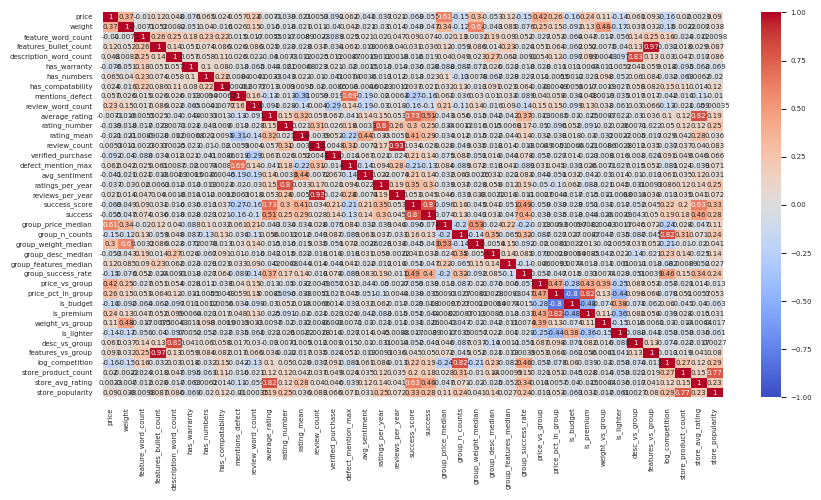

In [ ]:
corre_matrix=product_df.select_dtypes(include=['float64','int64']).corr()
matplotlib.rcParams['font.size'] = 5
plt.figure(figsize=(10,5))
sns.heatmap(
    data=corre_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

In [ ]:
product_df[product_df['launch_year'] >product_df['first_review_date']]


,asin,parent_asin,main_category,store,product_name,price,weight,dimension_d,launch_year,feature_word_count,features_bullet_count,description_word_count,has_warranty,has_numbers,has_compatability,mentions_defect,review_word_count,first_review_date,last_review_date,review_year_count,average_rating,rating_number,rating_mean,review_count,verified_purchase,defect_mention_count,avg_sentiment,launch_month,product_age,ratings_per_year,reviews_per_year,success_score,atomic_category,broad_category


In [ ]:
product_df[product_df['weight'].isna()][['product_name','weight','atomic_category']]

,product_name,weight,atomic_category


some column like electronic warrenties don't have weight column so what to do with that

In [ ]:
columns=product_df.select_dtypes(include=['float64','int64']).columns
columns
for i in columns:
  fig=px.histogram(data_frame=product_df,x=i, title=f"{i}")
  fig.show()

next is group by category and find the group wise ratios

letsdefine a dumbe succss score based on that define some eda transformations

What it is: EPS stands for Epsilon. It is a tiny number ($0.000001$).Why it's used: In the math below, we are dividing by the group median. If a group happens to have a median price of $0$, the computer will crash (it can't divide by zero). Adding this tiny number is like adding a drop of water to a dry well—it keeps the math flowing without changing your results

eda 2nd part

imshow to show matrix ina image format

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import LabelEncoder
#_______________________________________________________________
# EDA
# -------------------------------------------------------
numeric_columns=product_df.select_dtypes(include=['float64','int64']).columns
categorical_columns=product_df.select_dtypes(include=['object']).columns
corr=product_df[numeric_columns].corr().round(2)
fig=px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title='Correlation Matrix product level',
    width=1000,
    height=900,
    zmin=-1,zmax=1
)
fig.show()
# What to look for:
# 1. Which features correlate with 'success' (last row/column)
# 2. Which features correlate with each other > 0.85 (redundant, drop one)

cat_success=(
    product_df.groupby('atomic_category')['success']
    .agg(['mean','count'])
    .reset_index()
    .rename(columns={'mean':'success_rate','count':'n_products'})
    .sort_values('success_rate',ascending=False)
)

# Get the unique mapping from atomic_category to broad_category
atomic_to_broad_map = product_df[['atomic_category', 'broad_category']].drop_duplicates()

# Merge this mapping into cat_success
cat_success = cat_success.merge(atomic_to_broad_map, on='atomic_category', how='left')

fig=px.bar(
    data_frame=cat_success,
    x='atomic_category',
    y='success_rate',
    text='n_products',
    title='Success Rate by Category',
    labels={'success_rate': 'Success Rate', 'broad_category': 'Category'},
    color='success_rate',
    color_continuous_scale='RdYlGn',

)
fig.update_traces(texttemplate='n=%{text}',textposition='outside')

fig.update_layout(xaxis_tickangle=45)
fig.show()
# price vs success
fig=px.box(
    data_frame=product_df,
    x='success',
    y='price',
    title='Price vs Success',
    labels={'success': 'Success', 'price': 'Price'},
    color='success',
    color_discrete_map={0: '#e74c3c', 1: '#2ecc71'},
)
price_cap=product_df['price'].quantile(0.95)
fig.update_layout(yaxis_range=[0, price_cap])
fig.show()

# weight vs success
fig=px.box(
    data_frame=product_df,
    x='success',
    y='weight',
    title='Weight vs Success',
    labels={'success': 'Success', 'weight': 'Weight'},
    color='success',
    color_discrete_map={0: '#e74c3c', 1: '#2ecc71'},
)
weight_cap=product_df['weight'].quantile(0.95)
fig.update_layout(yaxis_range=[0, weight_cap])
fig.show()
# rating per year vs success
fig = px.box(
    product_df,
    x='success', y='ratings_per_year',
    color='success',
    title='Ratings Per Year: Success vs Failure',
    color_discrete_map={0: '#e74c3c', 1: '#2ecc71'},
)
rpy_cap = product_df['ratings_per_year'].quantile(0.95)
fig.update_yaxes(range=[0, rpy_cap])
fig.show()

# ── 6. Feature bullet count vs success ───────────────────────
fig = px.histogram(
    product_df,
    x='features_bullet_count',
    color='success',
    barmode='overlay',
    title='Feature Bullet Count: Success vs Failure',
    color_discrete_map={0: '#e74c3c', 1: '#2ecc71'},
    opacity=0.7,
    nbins=30,
)
fig.show()

# warrent vs success
warrenty_success=(
    product_df.groupby('has_warranty')['success'].mean().reset_index()
        .rename(columns={'success':'success_rate'})
    )

warrenty_success['label']=warrenty_success['has_warranty'].map(
    {0:'No Warrenty',1:'Has Warrenty'}
)

fig = px.bar(
    warrenty_success,
    x='label', y='success_rate',
    title='Success Rate: Warranty vs No Warranty',
    color='success_rate',
    color_continuous_scale='RdYlGn',
    text='success_rate',
)
fig.update_traces(texttemplate='%{text:.1%}', textposition='outside')
fig.show()

# ── 8. Price vs group (relative) vs success ───────────────────
fig = px.box(
    product_df,
    x='success', y='price_vs_group',
    color='success',
    title='Price vs Group Median: Success vs Failure',
    labels={'price_vs_group': 'Price / Group Median (1.0 = at median)'},
    color_discrete_map={0: '#e74c3c', 1: '#2ecc71'},
)
fig.add_hline(y=1.0, line_dash='dash',
              annotation_text='Category median')
fig.update_yaxes(range=[0, 3])
fig.show()

# ── 9. Success score distribution ────────────────────────────
fig = px.histogram(
    product_df,
    x='success_score',
    color='success',
    barmode='overlay',
    title='Success Score Distribution',
    color_discrete_map={0: '#e74c3c', 1: '#2ecc71'},
    opacity=0.7,
    nbins=50,
)
threshold = product_df['success_score'].quantile(0.50)
fig.add_vline(x=threshold, line_dash='dash',
              annotation_text=f'Threshold: {threshold:.2f}')
fig.show()


# ── 10. Print key stats ───────────────────────────────────────
print("=" * 55)
print("KEY EDA FINDINGS")
print("=" * 55)

# Feature correlations with success
corr_with_success = (
    product_df[numeric_columns]
    .corr()['success']
    .drop('success')
    .abs()
    .sort_values(ascending=False)
)
print("\nTop features correlated with success:")
print(corr_with_success.head(10).round(3).to_string())

print(f"\nOverall success rate  : {product_df['success'].mean():.1%}")
print(f"Success score range   : {product_df['success_score'].min():.3f} – "
      f"{product_df['success_score'].max():.3f}")
print(f"\nSuccess rate by category:")
print(cat_success[['atomic_category','success_rate','n_products']]
      .to_string(index=False))

KEY EDA FINDINGS

Top features correlated with success:
success_score          0.802
average_rating         0.509
store_avg_rating       0.462
group_success_rate     0.398
ratings_per_year       0.297
rating_mean            0.285
store_popularity       0.284
rating_number          0.249
log_competition        0.191
store_product_count    0.185

Overall success rate  : 40.0%
Success score range   : 0.011 – 0.835

Success rate by category:
                     atomic_category  success_rate  n_products
              Calculator Accessories      1.000000           2
                            Sandbags      1.000000           6
                   Connecting Blocks      1.000000           1
                     Mini-SAS Cables      1.000000           2
               Media Storage Sleeves      1.000000           1
                        Power Strips      0.892857          84
                       Step-Up Rings      0.800000          15
         Portable Bluetooth Speakers      0.787356    

In [ ]:
from google.colab import files
product_df.to_parquet("productdf.parquet")
files.download("productdf.parquet")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
productdf=pd.read_parquet('/content/productdf.parquet')

In [ ]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233 entries, 0 to 12232
Data columns (total 52 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   asin                    12233 non-null  object        
 1   parent_asin             12233 non-null  object        
 2   main_category           12233 non-null  object        
 3   store                   12233 non-null  object        
 4   product_name            12233 non-null  object        
 5   price                   12233 non-null  float64       
 6   weight                  12233 non-null  float64       
 7   dimension_d             11278 non-null  object        
 8   launch_year             12233 non-null  datetime64[ns]
 9   feature_word_count      12233 non-null  float64       
 10  features_bullet_count   12233 non-null  float64       
 11  description_word_count  12233 non-null  float64       
 12  has_warranty            12233 non-null  float6

In [ ]:
productdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233 entries, 0 to 12232
Data columns (total 52 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   asin                    12233 non-null  object        
 1   parent_asin             12233 non-null  object        
 2   main_category           12233 non-null  object        
 3   store                   12233 non-null  object        
 4   product_name            12233 non-null  object        
 5   price                   12233 non-null  float64       
 6   weight                  12233 non-null  float64       
 7   dimension_d             11278 non-null  object        
 8   launch_year             12233 non-null  datetime64[ns]
 9   feature_word_count      12233 non-null  float64       
 10  features_bullet_count   12233 non-null  float64       
 11  description_word_count  12233 non-null  float64       
 12  has_warranty            12233 non-null  float6